# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:139394): dbind-WARNING **: 15:33:41.055: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 100,
     'N_sol': 20}                       # number of solutions (individuals, networks) considered in the simulation

nrd.seed(1234)

In [3]:
solutions, fmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean fitness: 6.630291426444282e+48
Parents indexes: [[0 2]
 [0 3]
 [0 2]
 [0 1]
 [0 1]
 [0 2]
 [0 3]
 [0 1]]
Selection Probabilities: [9.99997683e-01 1.00034335e-06 7.87643506e-07 5.28570289e-07
 7.32603961e-13 1.06191831e-14 3.74175132e-15 2.56809410e-17
 2.07781600e-21 3.42614638e-22 1.36495760e-23 1.26735053e-23
 5.50541431e-24 3.04333815e-25 1.50587832e-25 1.28525122e-25
 5.59338345e-26 6.95577744e-28 3.08129755e-29 3.05435833e-30]
Inverse fitnesses: [1.01364256e-05 1.01399294e-11 7.98390830e-12 5.35782583e-12
 7.42600276e-18 1.07640809e-19 3.79280718e-20 2.60313551e-22
 2.10616761e-26 3.47289584e-27 1.38358232e-28 1.28464342e-28
 5.58053519e-29 3.08486422e-30 1.52642590e-30 1.30278836e-30
 5.66970466e-31 7.05068839e-33 3.12334158e-34 3.09603477e-35]
Iteration #1...
Mean fitness: 1.6378446570931117e+17
Parents indexes: [[0 3]
 [0 1]
 [1 0]
 [1 0]
 [0 5]
 [3 0]
 [0 1]
 [0 5]]
Selection Probabilities: [7.63069990e-001 1.08932478e-001 7.98515407e-002 2.22917454e-002
 

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 16


In [5]:
s = copy.deepcopy(solutions)
for sol in s[:20]:
    fitness = m.compute_fitness(sol,par,verb=True)
    print(f'Fitness:{fitness}')

Input: [0, 0] -> Output: 0.5574927074731073
Target distance:0.09659547070288696
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: 0.5300238213174501
Target distance:0.048786917949513196
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: 0.5274462601744819
Target distance:0.04986603278402874
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: 0.48873911583007246
Target distance:0.057056929334198675
Volume cost:1.7485144457345807e-06
Fitness:(0.25116328904097834, 0.9938486877801921, 0.005289256198347107)
Input: [0, 0] -> Output: 0.18764165547216427
Target distance:0.0012397012053191497
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: -0.2971681807385508
Target distance:2.831295168999619
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: 0.3053460583963768
Target distance:0.23284880707964453
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: -0.1660517404513865
Target distance:0.0007602802832679994
Volume cost:1.7485144457345807e-06


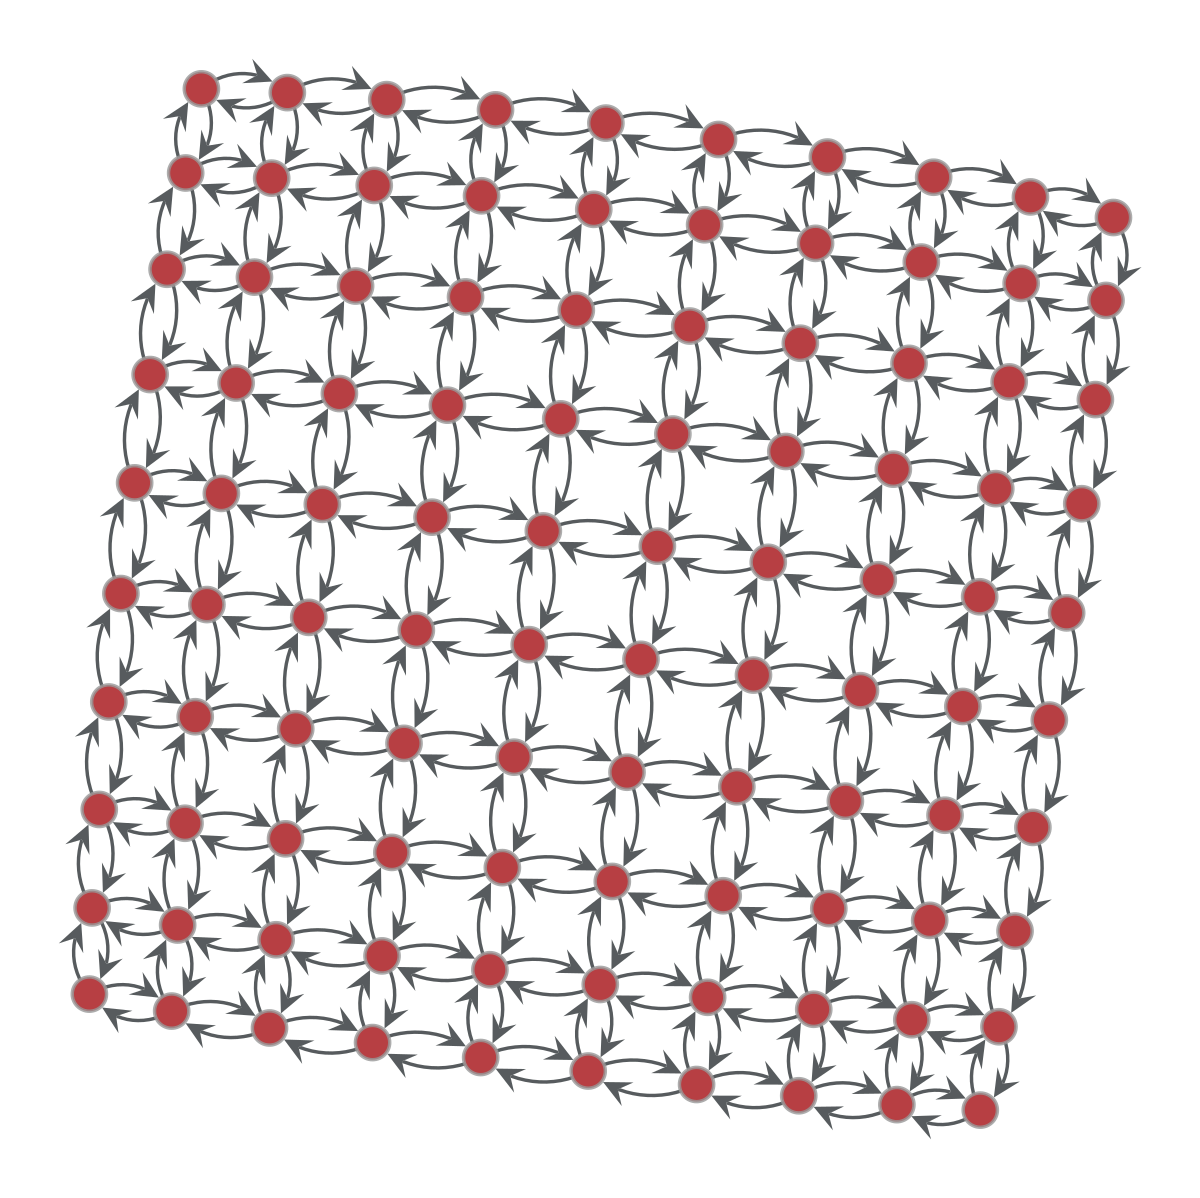

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7e30778c83b0, at 0x7e3125e5e7b0>

In [9]:
graph_draw(s[0].G)

In [10]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.036


In [17]:
np.array([sol.fitness for sol in s])

array([2.51811770e-01, 8.36037403e-01, 3.23615931e-01, 1.46838331e+00,
       1.43867126e+10, 3.48495295e-01, 1.88970254e+10, 2.83117990e-01,
       3.85667472e+00, 1.06640164e+01, 1.77836511e-01, 5.19932768e-01,
       1.22477318e+10, 3.28354756e-01, 8.94463083e+07, 2.33099816e+01,
       4.42827902e-01, 2.56504804e-01, 6.69339428e-01, 3.92439671e+00])

In [19]:
for input in par['input_set']:
    output = m.ff(input,s[0],par)
    print(f'Input:{input} -> Output:{output}')

Input:[0, 0] -> Output:0.5502575776518572
Input:[0, 1] -> Output:0.5128864398866589
Input:[1, 0] -> Output:0.5561739957322341
Input:[1, 1] -> Output:0.4903096100448929


In [16]:
mean_fit = np.mean(np.array([sol.fitness for sol in s]))
print(mean_fit)

2281045805.84905


In [11]:
def plot_T(T:np.ndarray,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    f_n = np.fft.irfft(T)
    coeff = np.polyfit(par['x_n'],f_n,3)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    x = np.linspace(-10,10,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

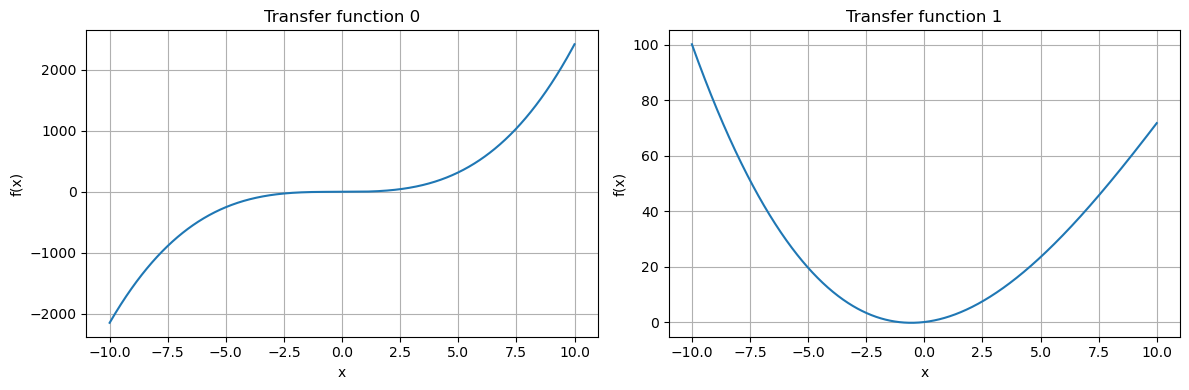

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

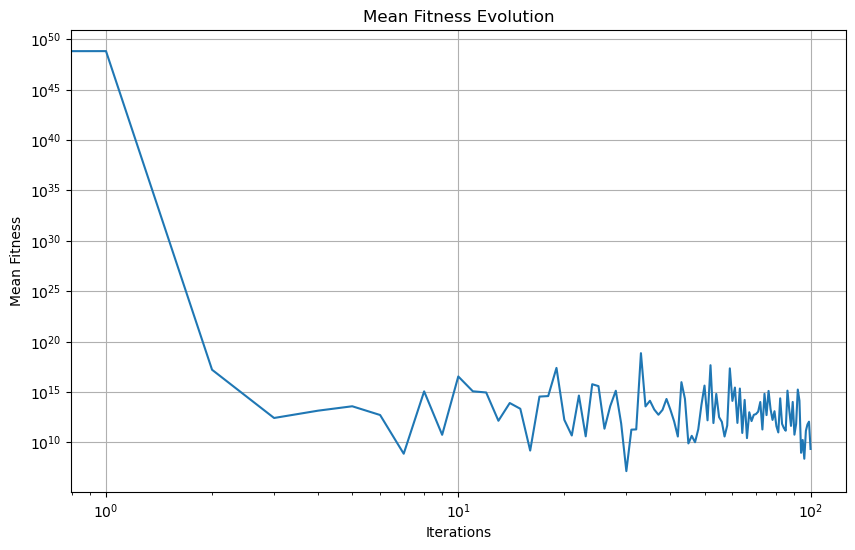

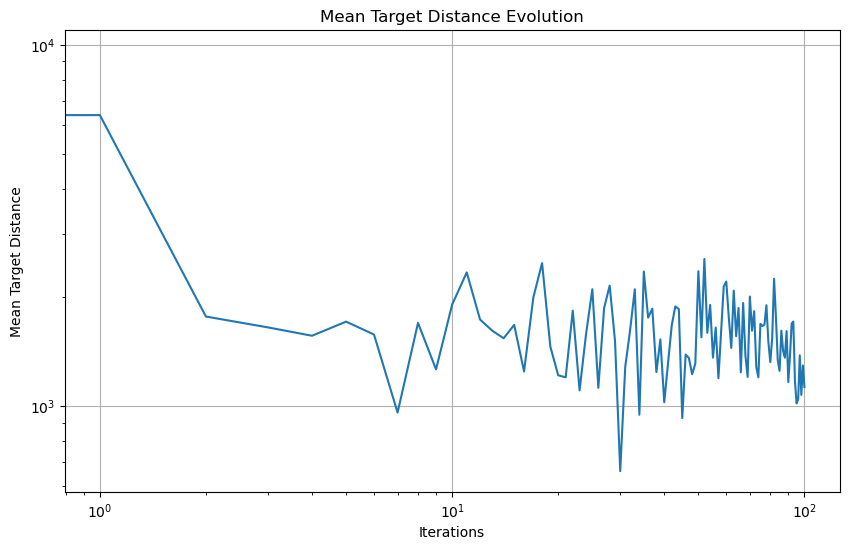

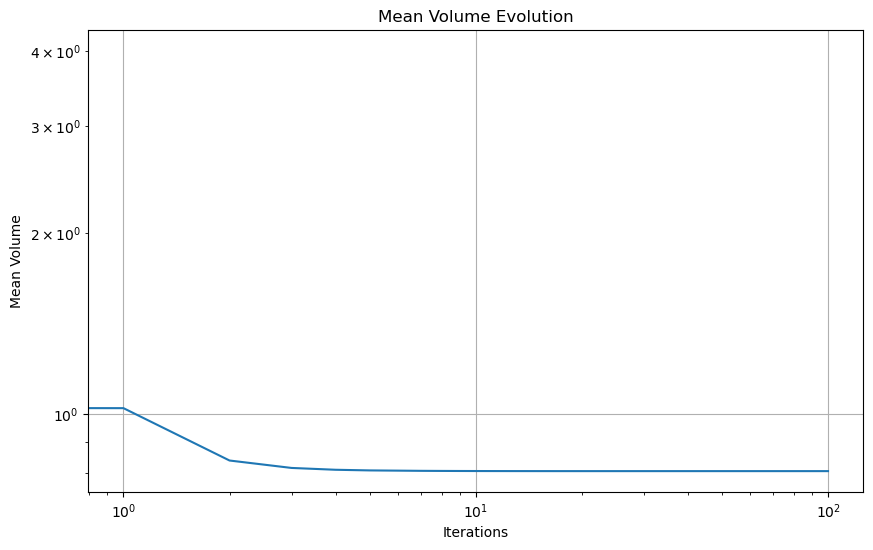

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(fmean)
plt.title('Mean Fitness Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Fitness')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()